In [269]:
import pandas as pd
import numpy as np

In [270]:
df=pd.read_csv("/powerplant_data.csv")

In [271]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [272]:
#temp,vaccum,pressurer,humidity
#pe=produced energy

In [273]:
df.isnull().sum()


,0
AT,0
V,0
AP,0
RH,0
PE,0


In [274]:
X=df.drop("PE",axis=1)
y=df["PE"]

In [275]:
from sklearn.model_selection import train_test_split

In [276]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

In [277]:
X_train

,AT,V,AP,RH
5487,25.24,63.47,1011.30,66.21
3522,26.09,70.40,1007.41,85.37
6916,26.63,73.68,1015.15,85.13
7544,32.06,71.85,1007.90,56.44
7600,28.70,71.64,1007.11,69.85
...,...,...,...,...
5734,26.25,61.02,1011.47,71.22
5191,29.17,64.79,1016.43,61.05
5390,18.00,43.70,1015.40,61.28
860,26.73,68.84,1010.75,66.83


In [278]:
df.shape

(9568, 5)

In [279]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
X_train_sc=std.fit_transform(X_train)
X_test_sc=std.transform(X_test)

In [280]:
import torch
import torch.nn as nn

In [281]:
X_train_tensor=torch.tensor(X_train_sc,dtype=torch.float32 )
X_test_tensor=torch.tensor(X_test_sc,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train.values,dtype=torch.float32).view(-1,1)
y_test_tensor=torch.tensor(y_test.values,dtype=torch.float32).view(-1,1)



In [282]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)


In [283]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)



#ANN FOR REGRESSION


In [284]:
import torch
import torch.nn as nn

# define ANN model
class ANN(nn.Module):

    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(

            # 1st hidden layer
            nn.Linear(X_train.shape[1], 6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6, 6),
            nn.ReLU(),

            # output layer
            nn.Linear(6, 1)
        )

    def forward(self, x):
        return self.model(x)

In [285]:
import torch.optim as optim

model = ANN()

criterion = nn.MSELoss()

optimizer = optim.Adam(model.parameters(), lr=0.001)

In [286]:
# training our ANN

train_losses = []
test_losses = []
best_val_loss=float("inf")
epochs = 50

for epoch in range(epochs):

    # Training
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        outputs = model(xb)

        loss = criterion(outputs, yb)

        loss.backward()

        optimizer.step()

        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_losses.append(epoch_train_loss)


    # Validation
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for xb, yb in test_loader:

            outputs = model(xb)

            loss = criterion(outputs, yb)

            running_val_loss += loss.item()

    epoch_test_loss = running_val_loss / len(test_loader)
    test_losses.append(epoch_test_loss)

    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {epoch_train_loss:.4f} | Test Loss: {epoch_test_loss:.4f}")

    if epoch_test_loss<best_val_loss:
      best_val_loss=epoch_test_loss
      torch.save(model.state_dict(),"best_model.pt")

Epoch 1/50 | Train Loss: 206201.9763 | Test Loss: 204086.7792
Epoch 2/50 | Train Loss: 196810.8688 | Test Loss: 185046.9690
Epoch 3/50 | Train Loss: 165591.5029 | Test Loss: 142130.5540
Epoch 4/50 | Train Loss: 117052.5740 | Test Loss: 91949.8646
Epoch 5/50 | Train Loss: 71762.3439 | Test Loss: 52620.4145
Epoch 6/50 | Train Loss: 38741.9995 | Test Loss: 25854.6251
Epoch 7/50 | Train Loss: 18196.7733 | Test Loss: 11913.0210
Epoch 8/50 | Train Loss: 9242.4137 | Test Loss: 7256.5718
Epoch 9/50 | Train Loss: 6382.1074 | Test Loss: 5566.7821
Epoch 10/50 | Train Loss: 4962.3145 | Test Loss: 4417.7421
Epoch 11/50 | Train Loss: 3892.3471 | Test Loss: 3458.5420
Epoch 12/50 | Train Loss: 3014.1669 | Test Loss: 2692.1708
Epoch 13/50 | Train Loss: 2322.8096 | Test Loss: 2097.0557
Epoch 14/50 | Train Loss: 1810.9183 | Test Loss: 1646.2894
Epoch 15/50 | Train Loss: 1426.8598 | Test Loss: 1294.9307
Epoch 16/50 | Train Loss: 1120.9966 | Test Loss: 1018.0848
Epoch 17/50 | Train Loss: 885.8255 | Test Lo

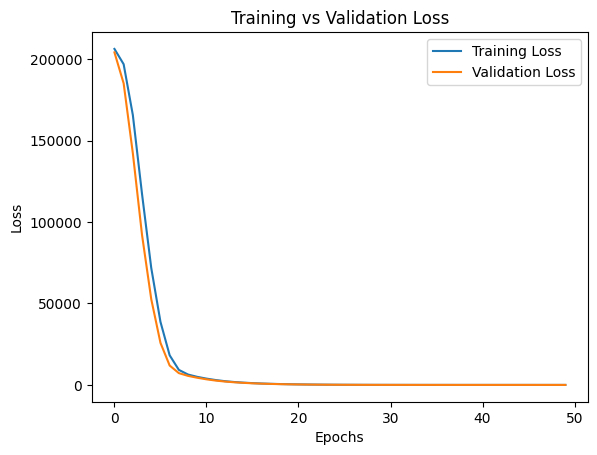

In [287]:
import pandas as pd
import matplotlib.pyplot as plt

loss_df = pd.DataFrame({
    "train_loss": train_losses,
    "val_loss": test_losses
})

plt.plot(loss_df["train_loss"], label="Training Loss")
plt.plot(loss_df["val_loss"], label="Validation Loss")

plt.legend()
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.show()

In [288]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [289]:
#Evaluation
model.eval()
with torch.no_grad():
 train_preds=model(X_train_tensor)
 test_preds=model(X_test_tensor)

 train_mse_loss=criterion(train_preds,y_train_tensor)
 test_mse_loss=criterion(test_preds,y_test_tensor)
 print("training MSE",train_mse_loss.item())
 print("testing MSE",test_mse_loss.item())

training MSE 21.08354377746582
testing MSE 19.28253936767578


In [290]:
from sklearn.metrics import r2_score
print("r2 score",r2_score(y_test,test_preds))


r2 score 0.9326125086231566


In [291]:
predicted_df=pd.DataFrame(test_preds.numpy(),columns=["Predicted values"])
actual_df=pd.DataFrame(y_test.values,columns=["Acutal values"])

pd.concat([predicted_df,actual_df],axis=1)


,Predicted values,Acutal values
0,435.477356,433.27
1,436.787292,438.16
2,460.735901,458.42
3,475.776672,480.82
4,434.789368,441.41
...,...,...
1909,451.491821,456.70
1910,431.586365,438.04
1911,467.978088,467.80
1912,430.926300,437.14


#ANN  FOR CALSSIFICATION


In [292]:
import pandas as pd
import numpy as np

In [293]:
df=pd.read_csv("/content/DateFruit_Dataset.csv")

In [294]:
df.head()

,AREA,PERIMETER,MAJOR_AXIS,MINOR_AXIS,ECCENTRICITY,EQDIASQ,SOLIDITY,CONVEX_AREA,EXTENT,ASPECT_RATIO,...,KurtosisRR,KurtosisRG,KurtosisRB,EntropyRR,EntropyRG,EntropyRB,ALLdaub4RR,ALLdaub4RG,ALLdaub4RB,Class
0,422163,2378.908,837.8484,645.6693,0.6373,733.1539,0.9947,424428,0.7831,1.2976,...,3.2370,2.9574,4.2287,-59191263232,-50714214400,-39922372608,58.7255,54.9554,47.8400,BERHI
1,338136,2085.144,723.8198,595.2073,0.5690,656.1464,0.9974,339014,0.7795,1.2161,...,2.6228,2.6350,3.1704,-34233065472,-37462601728,-31477794816,50.0259,52.8168,47.8315,BERHI
2,526843,2647.394,940.7379,715.3638,0.6494,819.0222,0.9962,528876,0.7657,1.3150,...,3.7516,3.8611,4.7192,-93948354560,-74738221056,-60311207936,65.4772,59.2860,51.9378,BERHI
3,416063,2351.210,827.9804,645.2988,0.6266,727.8378,0.9948,418255,0.7759,1.2831,...,5.0401,8.6136,8.2618,-32074307584,-32060925952,-29575010304,43.3900,44.1259,41.1882,BERHI
4,347562,2160.354,763.9877,582.8359,0.6465,665.2291,0.9908,350797,0.7569,1.3108,...,2.7016,2.9761,4.4146,-39980974080,-35980042240,-25593278464,52.7743,50.9080,42.6666,BERHI


In [295]:
df.isnull().sum()

,0
AREA,0
PERIMETER,0
MAJOR_AXIS,0
MINOR_AXIS,0
ECCENTRICITY,0
EQDIASQ,0
SOLIDITY,0
CONVEX_AREA,0
EXTENT,0
ASPECT_RATIO,0


In [296]:
df.shape

(898, 35)

In [297]:
X=df.drop("Class",axis=1)
y=df["Class"]

In [298]:
df["Class"].unique()

array(['BERHI', 'DEGLET', 'DOKOL', 'IRAQI', 'ROTANA', 'SAFAVI', 'SOGAY'],
      dtype=object)

In [299]:
from sklearn.model_selection import train_test_split

In [300]:
from sklearn.preprocessing import StandardScaler,LabelEncoder
le=LabelEncoder()
y=le.fit_transform(y)


In [301]:
X_train,X_test,y_train,y_test=train_test_split(
    X,y,test_size=0.2,random_state=42)

In [302]:
from sklearn.preprocessing import StandardScaler
std=StandardScaler()
X_train_sc=std.fit_transform(X_train)
X_test_sc=std.transform(X_test)

In [303]:
#ANN
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader,TensorDataset

In [304]:
X_train_tensor=torch.tensor(X_train_sc,dtype=torch.float32 )
X_test_tensor=torch.tensor(X_test_sc,dtype=torch.float32)
y_train_tensor=torch.tensor(y_train,dtype=torch.long)
y_test_tensor=torch.tensor(y_test,dtype=torch.long)



In [305]:
from torch.utils.data import TensorDataset,DataLoader

train_dataset=TensorDataset(X_train_tensor,y_train_tensor)
test_dataset=TensorDataset(X_test_tensor,y_test_tensor)


In [306]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
test_loader=DataLoader(test_dataset,batch_size=32)


In [307]:
import torch.nn as nn

# build model
class ANN(nn.Module):

    def __init__(self):
        super(ANN, self).__init__()

        self.model = nn.Sequential(
            nn.Linear(X.shape[1], 64),
            nn.ReLU(),

            nn.Linear(64, 64),
            nn.ReLU(),

            nn.Linear(64, 7)
        )

    def forward(self, x):
        return self.model(x)

In [308]:
model=ANN()


criteria=nn.CrossEntropyLoss()
optimizer=optim.Adam(model.parameters())

In [309]:
epochs=100
for epoch in range(epochs):
  model.train()
  running_loss=0.0
  for xb,yb in train_loader:
    optimizer.zero_grad()
    outputs=model(xb)
    loss=criteria(outputs,yb)
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
    train_loss=running_loss/len(train_loader)




In [310]:
# Evaluation

model.eval()

total = 0
correct = 0

with torch.no_grad():

    for xb, yb in test_loader:

        outputs = model(xb)

        _, predicted = torch.max(outputs, 1)

        correct += (predicted == yb).sum().item()

        total += yb.size(0)

accuracy = correct / total

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9388888888888889
